In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
#Task 1: Import the dataset

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Dataset Loaded: {X.shape[0]}  samples, {X.shape[1]}  features")
print(f"Classes: {target_names}\n")

Dataset Loaded: 569  samples, 30  features
Classes: ['malignant' 'benign']



In [5]:
#Task 2: Split the dataset for training and test set

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} ")
print(f"Test set size: {X_test.shape[0]}\n")

Training set size: 455 
Test set size: 114



In [8]:
#Task 3: Implement Gaussian Naive Bayes

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
acc_gnb = accuracy_score(y_test, y_pred_gnb)

print(f"Gaussian Naive Bayes Accuracy: {acc_gnb: .4f}")

Gaussian Naive Bayes Accuracy:  0.9737


In [18]:
#Task 4: Try other Bayes classifiers

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Testing MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train_scaled, y_train)
y_pred_mnb = mnb.predict(X_test_scaled)
acc_mnb = accuracy_score(y_test, y_pred_mnb)


#Testing BernoulliNB

bnb = BernoulliNB()
bnb.fit(X_train_scaled, y_train)
y_pred_bnb = bnb.predict(X_test_scaled)
acc_bnb = accuracy_score(y_test, y_pred_bnb)

print(f"Multinomial Naive Bayes Accuracy: {acc_mnb: .4f}")
print(f"Bernoulli Naive Bayes Accuracy: {acc_bnb: .4f}")

#Determing best model

best_model = gnb
best_name = "GaussianNB"
if acc_mnb > acc_gnb and acc_mnb > acc_bnb:
    best_model = mnb
    best_name = "MultinomialNB"
    y_pred_best = y_pred_mnb
elif acc_bnb > acc_gnb:
  best_model = bnb
  best_name = "BernoulliNB"
  y_pred_best = y_pred_bnb
else:
  y_pred_best = y_pred_gnb

print(f"\nBest Model selected:  {best_name}\n")


Multinomial Naive Bayes Accuracy:  0.8509
Bernoulli Naive Bayes Accuracy:  0.6228

Best Model selected:  GaussianNB



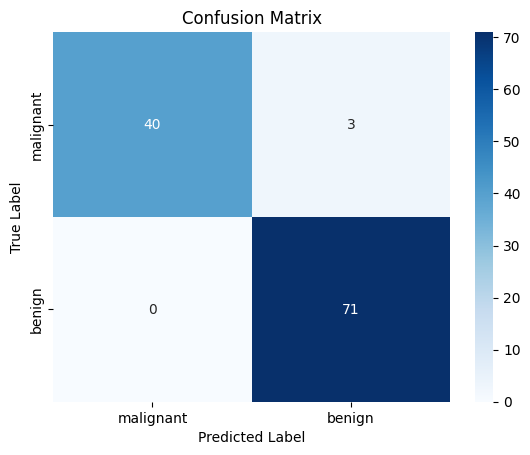

In [22]:
#Task 5: Generate and plot Confusion Matrix

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix')
plt.show()

In [25]:
#Task 6: Evaluate performance

print("Classification Report")
print(classification_report(y_test, y_pred_best, target_names=target_names))
print(f"Final Accuracy: {accuracy_score(y_test, y_pred_best)*100:2f}%")

Classification Report
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        43
      benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Final Accuracy: 97.368421%


In [26]:
#Task 7: Text a new example

new_sample = np.mean(X, axis=0).reshape(1,-1)

if best_name == "GaussianNB":
  new_sample_scaled = scaler.transform(new_sample)
  prediction = best_model.predict(new_sample_scaled)
else:
  prediction = best_model.predict(new_sample)

predicted_class = target_names[prediction[0]]

print(f"\n New Sample Prediction")
print(f"New Sample (Mean of all features): {new_sample}")
print(f"Predicted Class: {predicted_class}")


 New Sample Prediction
New Sample (Mean of all features): [[1.41272917e+01 1.92896485e+01 9.19690334e+01 6.54889104e+02
  9.63602812e-02 1.04340984e-01 8.87993158e-02 4.89191459e-02
  1.81161863e-01 6.27976098e-02 4.05172056e-01 1.21685343e+00
  2.86605923e+00 4.03370791e+01 7.04097891e-03 2.54781388e-02
  3.18937163e-02 1.17961371e-02 2.05422988e-02 3.79490387e-03
  1.62691898e+01 2.56772232e+01 1.07261213e+02 8.80583128e+02
  1.32368594e-01 2.54265044e-01 2.72188483e-01 1.14606223e-01
  2.90075571e-01 8.39458172e-02]]
Predicted Class: malignant
